# Knocking out an induction head

[*Induction heads in the wild*](https://barmag.github.io/) found the hand-crafted circuit inside GPT-2 small and Pythia-160m: a previous-token head (GPT-2 **L4H11**, Pythia **L3H2**) feeding a K-composed induction head (GPT-2 **L5H5**, Pythia **L4H6**), with a copying OV. Every one of those findings was **correlational**. A matrix looked right. A score was high. A rank was 1.

That notebook ended on a promise:

> Knock out L4H11 and L5H5, or L3H2 and L4H6, and watch whether the induction score collapses. That is the next notebook.

This is that notebook. We cut heads out of the forward pass and watch what breaks.

**Hypotheses.**

1. **H1 (knock-out).** If L5H5 / L4H6 *is* the induction head, removing it should collapse induction behavior — the model should lose its ability to predict the repeated half of a repeated random sequence. Predicted wrinkle: only a *partial* collapse, because the wild notebook already showed the behavior lives in a small cluster (GPT-2's L6H9 scores 0.917 against L5H5's 0.930).
2. **H2 (mediation).** If K-composition is causal, removing the *previous-token* head should kill the *induction* head's attention stripe — an effect one layer removed from the intervention.
3. **H3 (stretch).** If Pythia L4H6's negative OV eigenvalue mass is non-copying work sharing the same head, surgically removing those directions should preserve induction while costing something elsewhere.

**Papers.** Olsson et al. 2022, [*In-context Learning and Induction Heads*](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html) (ablations, per-token induction loss); Wang et al. 2023, [*Interpretability in the Wild*](https://arxiv.org/abs/2211.00593) (backup heads — the hydra effect); Elhage et al. 2021, [*A Mathematical Framework for Transformer Circuits*](https://transformer-circuits.pub/2021/framework/index.html) (OV eigenvalues).


In [1]:
import os
os.environ.setdefault("HSA_OVERRIDE_GFX_VERSION", "11.0.0")  # Strix Halo gfx1151 runs the gfx1100 wheels

import subprocess
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformer_lens import HookedTransformer, utils

SEED = 42
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"device={device}  seed={SEED}  commit={commit}")
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device=cuda  seed=42  commit=0f71b07
GPU: AMD Radeon 8060S Graphics


## Act 0 — The yardstick

Olsson et al. measure induction with a **repeated random sequence**: sample a block of random tokens, concatenate it with itself, and ask the model to predict. The first copy is unpredictable by construction — random tokens carry no signal, so the model can do no better than its prior. The second copy is perfectly predictable *if and only if* the model can look back, find where the current token appeared before, and copy what followed.

So the difference between those two halves is the behavior itself, measured in nats:

> **induction loss gap** = mean loss on the first (unrepeated) half − mean loss on the second (repeated) half.

Positive by construction when induction works. Every intervention in this notebook is scored by how much of this gap it destroys:

> **collapse fraction** = (gap_clean − gap_ablated) / gap_clean

0% means the intervention did nothing. 100% means induction is gone.

Both models, same seed and batch as the previous notebook, so the numbers line up across the two.

In [2]:
gpt2 = HookedTransformer.from_pretrained("gpt2", device=device)
pythia = HookedTransformer.from_pretrained("pythia-160m", device=device)
MODELS = {"gpt2": gpt2, "pythia": pythia}

BATCH, T, GATE = 32, 50, 0.2


def repeated_tokens(model, batch=BATCH, block=T, seed=SEED):
    """[BOS, block, block] -> [batch, 2T+1]. Same generator and seed as the previous notebook."""
    g = torch.Generator().manual_seed(seed)
    block_toks = torch.randint(100, 50_000, (batch, block), generator=g)  # both vocabs exceed 50k
    bos = torch.full((batch, 1), model.tokenizer.bos_token_id, dtype=torch.long)
    return torch.cat([bos, block_toks, block_toks], dim=1).to(model.cfg.device)


def halves(lpt):
    """loss_per_token[:, i] scores predicting token i+1. Cols 0..T-1 = first copy, T..2T-1 = second."""
    return lpt[:, 0:T].mean().item(), lpt[:, T:2 * T].mean().item()


def loss_gap(lpt):
    first, second = halves(lpt)
    return first - second


TOKENS, BASE = {}, {}
for name, model in MODELS.items():
    TOKENS[name] = repeated_tokens(model)
    lpt = model(TOKENS[name], return_type="loss", loss_per_token=True)
    first, second = halves(lpt)
    BASE[name] = {"first": first, "second": second, "gap": first - second}
    print(f"{name}: first(unrepeated)={first:6.3f}  second(repeated)={second:5.3f}  "
          f"gap={first - second:6.3f} nats")


def collapse(gap_abl, name):
    return (BASE[name]["gap"] - gap_abl) / BASE[name]["gap"]

`torch_dtype` is deprecated! Use `dtype` instead!


/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/torch/nn/modules/module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at ../c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


Loaded pretrained model gpt2 into HookedTransformer


Loaded pretrained model pythia-160m into HookedTransformer


/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/transformer_lens/utilities/attention.py:27: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, w, b_).reshape(input.shape[0], input.shape[1], b.shape[0], b.shape[1])


gpt2: first(unrepeated)=13.190  second(repeated)=0.481  gap=12.709 nats


pythia: first(unrepeated)=23.443  second(repeated)=5.561  gap=17.881 nats


### Results — the gap is real, and the two models are not alike

**GPT-2 small:** 13.190 nats on the unrepeated half, **0.481** on the repeated half — a gap of **12.709 nats**. The second time it sees the sequence, GPT-2 predicts it at about half a nat per token. That is very close to knowing the answer.

**Pythia-160m:** 23.443 → **5.561**, a gap of **17.881 nats**. The gap is *larger*, but read the second number rather than the difference: Pythia still pays 5.6 nats per token on text it has already seen once. It is copying, but nothing like as cleanly as GPT-2 — despite Pythia's induction head scoring *higher* on the attention diagnostic in the previous notebook (0.987 vs 0.930). Attending to the right place and writing the right token are two different jobs, and the previous notebook already saw the seam: Pythia's copying-OV score was 0.423 against GPT-2's 0.816.

Both first-half losses sit above ln(50000) ≈ 10.8 nats, the cost of guessing uniformly among the token IDs we sampled from. That is expected: a language model is not a uniform prior over token IDs. It finds a random draw from the middle of the vocabulary *less* likely than chance would, and Pythia — whose tokenizer and training mix differ from GPT-2's — finds it much less likely still. This is why the two models' absolute nats are not comparable to each other, and why every intervention below is scored as a **fraction of that model's own gap** rather than in raw nats.

The gap is the yardstick. Now we start cutting.

## Act 1 — Calibrate the scalpel

To remove a head we replace its output with something else. The naive choice is **zero**: set the head's `hook_z` (its per-head output, before `W_O`) to 0. But zero is not a neutral value. A trained network never sees a head output zero; the rest of the model has no idea what to do with it. Zeroing takes the model **off-distribution**, and then any damage you measure is partly the damage of feeding the model an input it was never built for — not the loss of the head's job.

The standard fix, and what the interpretability literature settled on: **mean-ablation**. Replace the head's output with its *average* output over a reference distribution. The head stops carrying information about *this particular sequence*, but the downstream layers still receive a vector of the size and shape they expect. What you subtract is the head's signal, not its existence.

We show both, once, on GPT-2's L5H5 — then use mean-ablation everywhere after.

In [3]:
def z_means(model, ref_tokens):
    """Per-head mean hook_z over batch and position: {layer: [n_heads, d_head]}."""
    _, cache = model.run_with_cache(
        ref_tokens, return_type=None, names_filter=lambda n: n.endswith("hook_z")
    )
    return {l: cache["z", l].mean(dim=(0, 1)) for l in range(model.cfg.n_layers)}


# Reference batch: same distribution as the eval batch, disjoint draw.
ZM = {name: z_means(m, repeated_tokens(m, seed=SEED + 1000)) for name, m in MODELS.items()}


def ablation_hooks(targets, zm):
    """targets: [(layer, head), ...] -> TransformerLens fwd_hooks replacing each head's z."""
    by_layer = defaultdict(list)
    for layer, head in targets:
        by_layer[layer].append(head)

    def make(heads, layer):
        def hook(z, hook):          # z: [batch, pos, head, d_head]
            for h in heads:
                z[:, :, h, :] = zm[layer][h]
            return z
        return hook

    return [(utils.get_act_name("z", l), make(hs, l)) for l, hs in by_layer.items()]


def run_ablated(model, tokens, targets, zm, names_filter=None):
    hooks = ablation_hooks(targets, zm)
    if names_filter is None:
        return model.run_with_hooks(tokens, return_type="loss", loss_per_token=True, fwd_hooks=hooks)
    with model.hooks(fwd_hooks=hooks):
        return model.run_with_cache(tokens, return_type=None, names_filter=names_filter)


IND = {"gpt2": (5, 5), "pythia": (4, 6)}      # induction heads, from the previous notebook
PREV = {"gpt2": (4, 11), "pythia": (3, 2)}    # previous-token heads

ZERO = {name: {l: torch.zeros_like(v) for l, v in zm.items()} for name, zm in ZM.items()}

CALIB = {}
for kind, ref in [("mean", ZM), ("zero", ZERO)]:
    lpt = run_ablated(gpt2, TOKENS["gpt2"], [IND["gpt2"]], ref["gpt2"])
    CALIB[kind] = collapse(loss_gap(lpt), "gpt2")
    print(f"GPT-2 L5H5 {kind}-ablated: gap={loss_gap(lpt):6.3f}  "
          f"collapse={CALIB[kind]:5.1%}  (clean gap {BASE['gpt2']['gap']:.3f})")

GPT-2 L5H5 mean-ablated: gap=12.621  collapse= 0.7%  (clean gap 12.709)
GPT-2 L5H5 zero-ablated: gap=12.694  collapse= 0.1%  (clean gap 12.709)


### Results — the scalpel is calibrated, and it cuts nothing

Mean-ablating L5H5 destroys **0.7%** of the induction gap (12.709 → 12.621). Zero-ablating it destroys **0.1%** (12.709 → 12.694).

Two things to take from this, and it matters which is which.

**The methodological point stands.** Mean-ablation is the right default and we use it for the rest of the notebook: it removes a head's information without handing the downstream layers a vector they have never seen. Nothing below depends on the choice, but the reasoning is load-bearing whenever an ablation *does* bite.

**The honest point is that here, neither tool bites at all.** The interesting number is not the difference between 0.7% and 0.1% — both are, to a first approximation, zero. We just deleted the head that the previous notebook identified as GPT-2's induction head, the one scoring 0.930 on the induction diagnostic, and the model's ability to exploit a repeated sequence is **essentially untouched**. It still predicts the repeated half at 0.5 nats per token.

That is not a defect of the scalpel. It is the first real finding, and Act 2 is about taking it seriously.

## Act 2a — Knock out the induction head

Olsson et al. establish induction heads causally by ablating them and watching in-context learning degrade. So: mean-ablate the single best induction head each model has — GPT-2's L5H5 (score 0.930), Pythia's L4H6 (0.987) — and measure how much of the loss gap dies with it.

If "the induction head" is *the* induction head, this is where the behavior collapses.

In [4]:
def ind_scores(cache, model):
    """Induction attention score per head: mass at offset -(T-1), same definition as before."""
    q = torch.arange(T + 1, 2 * T + 1)
    out = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
    for layer in range(model.cfg.n_layers):
        out[layer] = cache["pattern", layer][:, :, q, q - T + 1].mean(dim=(0, 2)).cpu()
    return out


SCORES, LADDER = {}, {}
for name, model in MODELS.items():
    _, cache = model.run_with_cache(
        TOKENS[name], return_type=None, names_filter=lambda n: n.endswith("pattern")
    )
    SCORES[name] = ind_scores(cache, model)
    del cache
    lpt = run_ablated(model, TOKENS[name], [IND[name]], ZM[name])
    LADDER[name] = {"top-1": collapse(loss_gap(lpt), name)}
    l, h = IND[name]
    print(f"{name}: ablate L{l}H{h} (score {SCORES[name][l, h]:.3f})  "
          f"gap {BASE[name]['gap']:6.3f} -> {loss_gap(lpt):6.3f}   "
          f"collapse={LADDER[name]['top-1']:5.1%}")

gpt2: ablate L5H5 (score 0.930)  gap 12.709 -> 12.621   collapse= 0.7%


pythia: ablate L4H6 (score 0.987)  gap 17.881 -> 17.015   collapse= 4.8%


### Act 2b — The hydra check

Nothing collapsed. Before concluding the head does nothing, consider what *Interpretability in the Wild* found when it ablated GPT-2's name-mover heads: other heads **took over**. Wang et al. call them backup heads — heads that sit quiet in the clean model and step into the job when the primary is removed. Cut off one head, two grow back.

The previous notebook already flagged the suspects: L6H9 scores 0.917 on induction against L5H5's 0.930. That is not a runner-up, it is a twin.

So re-measure *every* head's induction score inside the ablated forward pass and compare to clean. If the runners-up strengthen, the circuit is a hydra and single-head ablation was never going to work.

gpt2: heads that strengthen most under L5H5 ablation
    L6H9: 0.917 -> 0.963 (+0.046)
    L7H11: 0.042 -> 0.069 (+0.027)
    L10H7: 0.473 -> 0.493 (+0.020)


pythia: heads that strengthen most under L4H6 ablation
    L8H10: 0.066 -> 0.092 (+0.026)
    L6H11: 0.045 -> 0.070 (+0.025)
    L5H0: 0.807 -> 0.823 (+0.017)


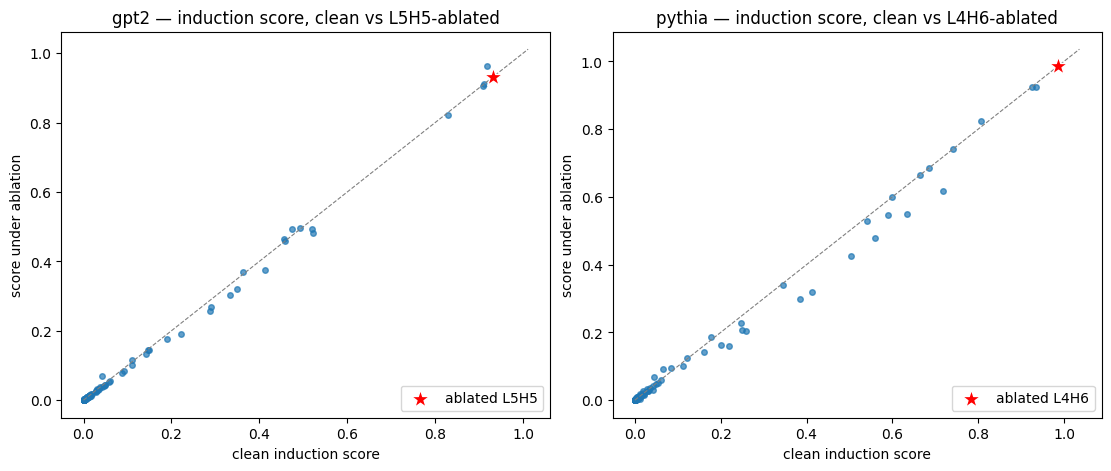

In [5]:
HYDRA = {}
for name, model in MODELS.items():
    _, cache = run_ablated(
        model, TOKENS[name], [IND[name]], ZM[name],
        names_filter=lambda n: n.endswith("pattern"),
    )
    HYDRA[name] = ind_scores(cache, model)
    del cache
    l, h = IND[name]
    delta = HYDRA[name] - SCORES[name]
    delta[l, h] = 0.0                       # the ablated head itself is not a backup
    flat = delta.flatten().argsort(descending=True)[:3]
    print(f"{name}: heads that strengthen most under L{l}H{h} ablation")
    for f in flat:
        ll, hh = divmod(f.item(), model.cfg.n_heads)
        print(f"    L{ll}H{hh}: {SCORES[name][ll, hh]:.3f} -> {HYDRA[name][ll, hh]:.3f} "
              f"({delta[ll, hh]:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for ax, (name, model) in zip(axes, MODELS.items()):
    x, y = SCORES[name].flatten(), HYDRA[name].flatten()
    ax.scatter(x, y, s=16, alpha=0.7)
    lims = [0, max(x.max().item(), y.max().item()) * 1.05]
    ax.plot(lims, lims, color="grey", lw=0.8, ls="--")
    l, h = IND[name]
    ax.scatter([SCORES[name][l, h]], [HYDRA[name][l, h]], marker="*", s=200, c="red",
               edgecolors="white", zorder=3, label=f"ablated L{l}H{h}")
    ax.set_title(f"{name} — induction score, clean vs L{l}H{h}-ablated")
    ax.set_xlabel("clean induction score")
    ax.set_ylabel("score under ablation")
    ax.legend(loc="lower right")
plt.show()

### Act 2c — Escalate

If one head is not the circuit, how many are? Take every head whose clean induction score clears 0.2 — the previous notebook's gate — and remove the whole set at once. Between the two, an intermediate rung: the top 3 heads by score.

This is the escalation ladder: one head, three heads, the whole cluster. Where the gap finally falls is a measurement of how distributed the behavior is.

gpt2: ablate top-3    (n= 3)  gap -> 10.072  collapse=20.7%
gpt2: ablate cluster  (n=18)  gap ->  2.266  collapse=82.2%
    gpt2 cluster: L5H0(0.46), L5H1(0.91), L5H5(0.93), L6H9(0.92), L7H1(0.22), L7H2(0.83), L7H10(0.91), L8H1(0.36), L9H0(0.29), L9H6(0.52), L9H9(0.49), L10H0(0.41), L10H1(0.52), L10H6(0.33), L10H7(0.47), L10H11(0.29), L11H9(0.35), L11H10(0.46)


pythia: ablate top-3    (n= 3)  gap -> 16.232  collapse= 9.2%
pythia: ablate cluster  (n=22)  gap ->  2.448  collapse=86.3%
    pythia cluster: L4H6(0.99), L4H8(0.66), L4H10(0.92), L4H11(0.68), L5H0(0.81), L5H6(0.74), L5H7(0.60), L8H2(0.93), L8H8(0.59), L8H11(0.54), L9H2(0.50), L9H4(0.25), L9H5(0.25), L9H6(0.56), L9H7(0.35), L9H8(0.72), L9H9(0.63), L10H6(0.41), L10H7(0.22), L10H8(0.26), L10H10(0.38), L10H11(0.20)


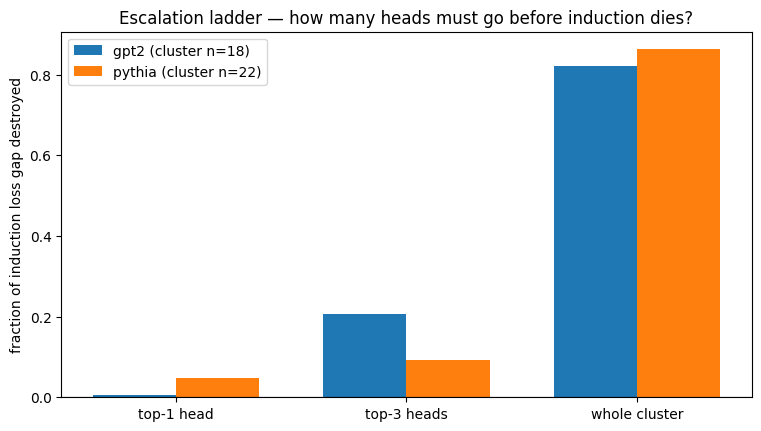

In [6]:
CLUSTER, TOP3 = {}, {}
for name, model in MODELS.items():
    n_heads = model.cfg.n_heads
    CLUSTER[name] = [(l, h) for l in range(model.cfg.n_layers) for h in range(n_heads)
                     if SCORES[name][l, h] > GATE]
    TOP3[name] = [divmod(f.item(), n_heads)
                  for f in SCORES[name].flatten().argsort(descending=True)[:3]]
    for label, targets in [("top-3", TOP3[name]), ("cluster", CLUSTER[name])]:
        lpt = run_ablated(model, TOKENS[name], targets, ZM[name])
        LADDER[name][label] = collapse(loss_gap(lpt), name)
        print(f"{name}: ablate {label:8s} (n={len(targets):2d})  gap -> {loss_gap(lpt):6.3f}  "
              f"collapse={LADDER[name][label]:5.1%}")
    print(f"    {name} cluster: " + ", ".join(f"L{l}H{h}({SCORES[name][l, h]:.2f})"
                                              for l, h in CLUSTER[name]))

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
rungs = ["top-1", "top-3", "cluster"]
width = 0.36
for i, name in enumerate(MODELS):
    ax.bar([r + (i - 0.5) * width for r in range(len(rungs))],
           [LADDER[name][r] for r in rungs], width,
           label=f"{name} (cluster n={len(CLUSTER[name])})")
ax.set_xticks(range(len(rungs)))
ax.set_xticklabels(["top-1 head", "top-3 heads", "whole cluster"])
ax.set_ylabel("fraction of induction loss gap destroyed")
ax.set_title("Escalation ladder — how many heads must go before induction dies?")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
plt.show()

### Results — Act 2

**The single head is not the circuit.** Ablating GPT-2's L5H5 destroys **0.7%** of the induction gap; ablating Pythia's L4H6 destroys **4.8%**. These are the heads the previous notebook identified by argmax, matching the heads Wang et al. name in print, scoring 0.930 and 0.987 on the induction diagnostic. Removing them entirely costs the models almost nothing.

**The hydra is real in GPT-2, and thinner than advertised.** Under L5H5 ablation, its twin **L6H9 rises 0.917 → 0.963** — the largest movement in the grid, and exactly the backup behavior Wang et al. describe: a head that steps up when the primary is cut. But notice the *size* of the step. L6H9 gains 0.046. It does not double. It was already doing the job at 0.917 before we touched anything.

Pythia shows no comparable twin at all: its biggest movers are L8H10 (0.066 → 0.092) and L6H11 (0.045 → 0.070), heads that barely do induction in the first place, and its strongest sibling L5H0 shifts only 0.807 → 0.823.

So "backup heads compensate" is the smaller half of the explanation. The larger half is that **there was never anything to compensate for**: the job was already spread across a dozen heads before the intervention. GPT-2 has 18 heads above the 0.2 gate; Pythia has 22. Cutting one of eighteen is not a lesion, it is a rounding error.

**The ladder shows how spread.** Three heads — the best induction heads each model has, all scoring ≥0.9 — buy only **20.7%** (GPT-2) and **9.2%** (Pythia). The behavior does not collapse until the whole above-gate cluster goes: **82.2%** with 18 heads (GPT-2), **86.3%** with 22 (Pythia).

That is the answer to H1, and it is the opposite of the clean story. Induction is not a head. It is a *population*, and the population is deeply redundant — 18 heads to destroy a behavior that any one of them appears, by attention score, to be performing almost completely on its own.

**The honest caveat, and what Act 4 does about it.** Ablating 18 of 144 heads (a quarter of layers 5–11) is a large lesion. An 82% collapse is *consistent with* "we removed induction", but it is equally consistent with "we broke the second half of the network." Nothing in this act separates the two. Act 4 is the control: if what we removed is induction-specific, the damage on real text should land on the positions where induction can act, and nowhere else.